# Hydropower Energy Production Prediction
## Machine Learning Project — Linear Regression
Author: Kaleab Zelalem | Source: UCI ML Repository

In [1]:
import micropip
await micropip.install(['numpy', 'pandas', 'matplotlib',
                        'seaborn', 'scikit-learn', 'openpyxl'])
print("All libraries installed!")

All libraries installed!


In [2]:
%pip install openpyxl

In [3]:
import pandas as pd

df = pd.read_excel('data/hydropower_data.xlsx')
print(df.shape)
display(df.head())

(1000, 9)


,Water_Flow_Rate (m³/s),Head (meters),Turbine_Efficiency (%),Generator_Efficiency (%),Reservoir_Level (meters),Gate_Opening (%),Ambient_Temperature (°C),Barometric_Pressure (mbar),Energy_Production (MW)
0,218.543053,17.405317,83.925585,93.745139,65.759670,45.427197,19.171563,953.879945,228.406276
1,477.821438,31.676038,83.704682,95.356858,84.434586,52.609209,-2.242614,968.677253,420.939777
2,379.397274,44.917833,93.593819,88.256083,80.812874,86.909265,29.257755,1033.124581,346.202500
3,319.396318,39.288995,83.743193,93.123363,32.311992,40.600395,17.590231,1026.676836,307.038023
4,120.208388,42.262446,84.079246,92.432698,31.939958,88.268472,-2.925825,985.064269,162.451343


# ============================================================
# CELL 1 — Imports & Global Configuration
# ============================================================

In [4]:
%pip install seaborn

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 12

# ── Reproducibility ───────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.30

print('Libraries loaded successfully.')
print(f'NumPy: {np.__version__}  |  Pandas: {pd.__version__}')


Libraries loaded successfully.
NumPy: 2.4.3  |  Pandas: 3.0.2


# ============================================================
# CELL 2 — Data Loading & Initial Inspection
# ============================================================


In [6]:
# Load dataset
df = pd.read_excel('data/hydropower_data.xlsx')

# ── Basic inspection ──────────────────────────────────────────
print('=== DATASET SHAPE ===')
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
print()

print('=== FIRST 5 ROWS ===')
display(df.head())

print('=== DATA TYPES & NULL CHECK ===')
display(df.info())

print('=== STATISTICAL SUMMARY ===')
display(df.describe().round(3))

print('=== MISSING VALUES ===')
print(df.isnull().sum())
print(f'Total missing values: {df.isnull().sum().sum()}')

=== DATASET SHAPE ===
Rows: 1000  |  Columns: 9

=== FIRST 5 ROWS ===


,Water_Flow_Rate (m³/s),Head (meters),Turbine_Efficiency (%),Generator_Efficiency (%),Reservoir_Level (meters),Gate_Opening (%),Ambient_Temperature (°C),Barometric_Pressure (mbar),Energy_Production (MW)
0,218.543053,17.405317,83.925585,93.745139,65.759670,45.427197,19.171563,953.879945,228.406276
1,477.821438,31.676038,83.704682,95.356858,84.434586,52.609209,-2.242614,968.677253,420.939777
2,379.397274,44.917833,93.593819,88.256083,80.812874,86.909265,29.257755,1033.124581,346.202500
3,319.396318,39.288995,83.743193,93.123363,32.311992,40.600395,17.590231,1026.676836,307.038023
4,120.208388,42.262446,84.079246,92.432698,31.939958,88.268472,-2.925825,985.064269,162.451343


=== DATA TYPES & NULL CHECK ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Water_Flow_Rate (m³/s)      1000 non-null   float64
 1   Head (meters)               1000 non-null   float64
 2   Turbine_Efficiency (%)      1000 non-null   float64
 3   Generator_Efficiency (%)    1000 non-null   float64
 4   Reservoir_Level (meters)    1000 non-null   float64
 5   Gate_Opening (%)            1000 non-null   float64
 6   Ambient_Temperature (°C)    1000 non-null   float64
 7   Barometric_Pressure (mbar)  1000 non-null   float64
 8   Energy_Production (MW)      1000 non-null   float64
dtypes: float64(9)
memory usage: 70.4 KB


None

=== STATISTICAL SUMMARY ===


,Water_Flow_Rate (m³/s),Head (meters),Turbine_Efficiency (%),Generator_Efficiency (%),Reservoir_Level (meters),Gate_Opening (%),Ambient_Temperature (°C),Barometric_Pressure (mbar),Energy_Production (MW)
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,270.615,30.281,87.536,91.375,59.528,54.862,12.199,998.237,267.389
std,131.462,11.688,4.360,3.724,22.945,26.028,13.038,28.491,92.432
min,52.084,10.129,80.000,85.008,20.002,10.557,-9.936,950.024,100.038
25%,156.188,19.643,83.920,88.145,39.598,32.444,0.810,973.599,187.013
50%,273.563,30.749,87.509,91.296,59.568,54.136,11.809,998.399,267.237
75%,384.944,40.419,91.387,94.588,79.199,76.587,24.041,1021.447,347.215
max,499.873,49.977,94.967,97.994,99.820,99.942,34.976,1049.890,442.614


=== MISSING VALUES ===
Water_Flow_Rate (m³/s)        0
Head (meters)                 0
Turbine_Efficiency (%)        0
Generator_Efficiency (%)      0
Reservoir_Level (meters)      0
Gate_Opening (%)              0
Ambient_Temperature (°C)      0
Barometric_Pressure (mbar)    0
Energy_Production (MW)        0
dtype: int64
Total missing values: 0


# ============================================================
# CELL 3 — Exploratory Data Analysis
# ============================================================


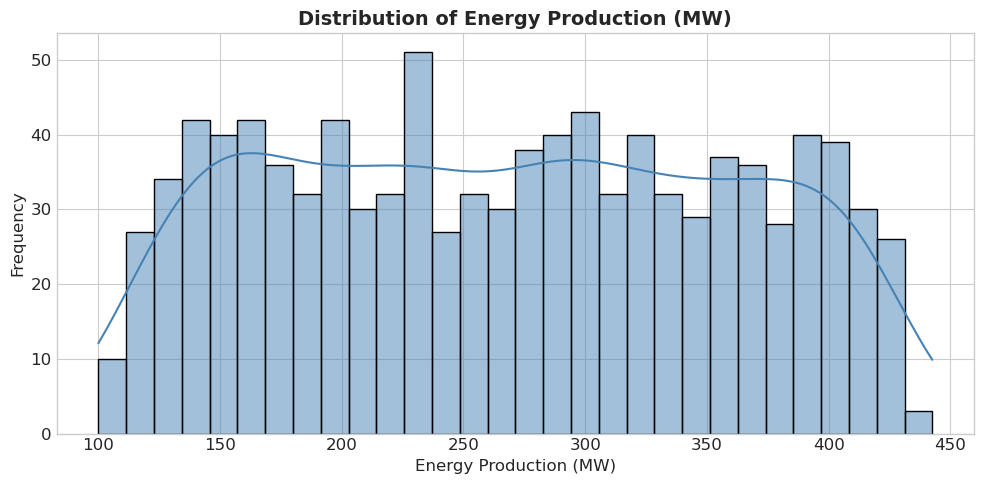

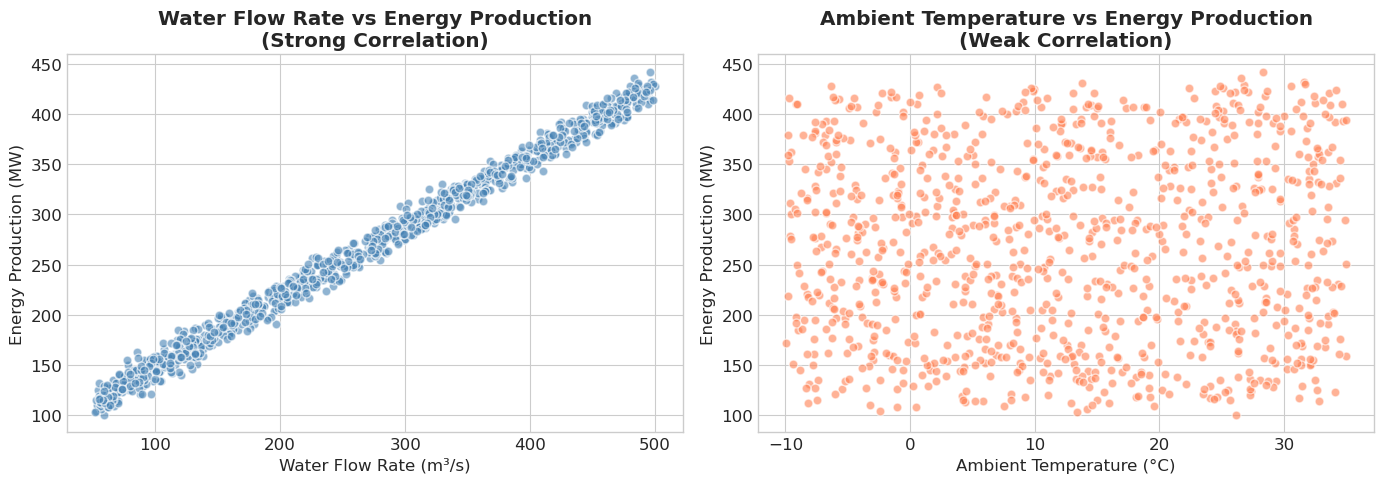

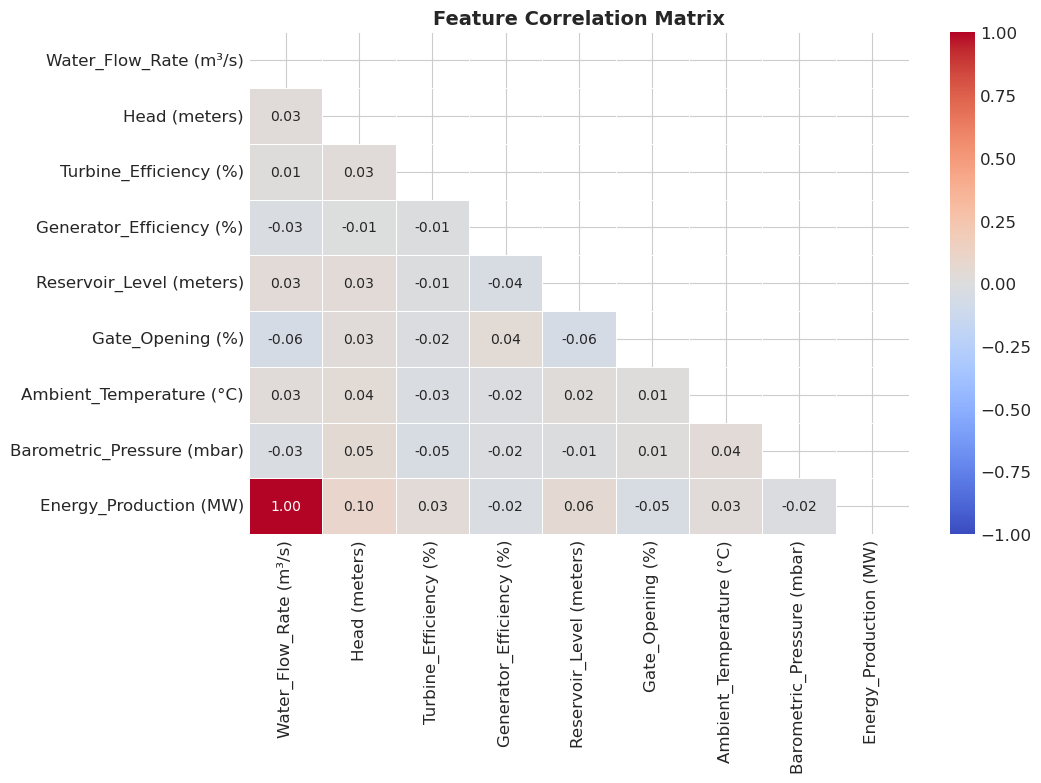

=== CORRELATION WITH TARGET (EnergyProduction) ===
Water_Flow_Rate (m³/s)        0.996
Head (meters)                 0.098
Reservoir_Level (meters)      0.060
Turbine_Efficiency (%)        0.032
Ambient_Temperature (°C)      0.030
Barometric_Pressure (mbar)   -0.019
Generator_Efficiency (%)     -0.025
Gate_Opening (%)             -0.046
Name: Energy_Production (MW), dtype: float64


In [7]:
# Define features and target
FEATURES = ['Water_Flow_Rate (m³/s)','Head (meters)','Turbine_Efficiency (%)',
            'Generator_Efficiency (%)','Reservoir_Level (meters)','Gate_Opening (%)',
            'Ambient_Temperature (°C)','Barometric_Pressure (mbar)']
TARGET   = 'Energy_Production (MW)'

# ── PLOT 1: Distribution of Target Variable ───────────────────
plt.figure(figsize=(10,5))
sns.histplot(df[TARGET], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Energy Production (MW)', fontsize=14, fontweight='bold')
plt.xlabel('Energy Production (MW)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('outputs/figures/01_target_distribution.png', dpi=150)
plt.show()

# ── PLOT 2: Scatter — Water Flow Rate vs Energy (STRONG) ──────
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].scatter(df['Water_Flow_Rate (m³/s)'], df[TARGET], alpha=0.6, color='steelblue', edgecolors='white', s=40)
axes[0].set_title('Water Flow Rate vs Energy Production\n(Strong Correlation)', fontweight='bold')
axes[0].set_xlabel('Water Flow Rate (m³/s)')
axes[0].set_ylabel('Energy Production (MW)')

# ── PLOT 3: Scatter — Ambient Temperature vs Energy (WEAK) ────
axes[1].scatter(df['Ambient_Temperature (°C)'], df[TARGET], alpha=0.6, color='coral', edgecolors='white', s=40)
axes[1].set_title('Ambient Temperature vs Energy Production\n(Weak Correlation)', fontweight='bold')
axes[1].set_xlabel('Ambient Temperature (°C)')
axes[1].set_ylabel('Energy Production (MW)')

plt.tight_layout()
plt.savefig('outputs/figures/02_scatter_plots.png', dpi=150)
plt.show()

# ── PLOT 4: Full Correlation Heatmap ─────────────────────────
plt.figure(figsize=(11,8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size':10})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/03_correlation_heatmap.png', dpi=150)
plt.show()

# ── Print top correlations with target ────────────────────────
print('=== CORRELATION WITH TARGET (EnergyProduction) ===')
print(corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False).round(3))


# ============================================================
# CELL 4 — Data Preprocessing & Train/Test Split
# ============================================================



In [8]:
# ── Separate features and target ─────────────────────────────
X = df[FEATURES]
y = df[TARGET]

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'Feature names:  {list(X.columns)}')

# ── Train / Test Split (70% / 30%) ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(f'\nTraining samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

# ── Feature Standardisation (required for SGD) ───────────────
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # transform only on test

# NOTE: We fit the scaler ONLY on training data.
# Fitting on test data would cause data leakage.
print('\nStandardisation complete.')
print('Linear Regression will use raw X_train/X_test.')
print('SGD Regression will use X_train_scaled/X_test_scaled.')


Features shape: (1000, 8)
Target shape:   (1000,)
Feature names:  ['Water_Flow_Rate (m³/s)', 'Head (meters)', 'Turbine_Efficiency (%)', 'Generator_Efficiency (%)', 'Reservoir_Level (meters)', 'Gate_Opening (%)', 'Ambient_Temperature (°C)', 'Barometric_Pressure (mbar)']

Training samples: 700
Testing samples:  300

Standardisation complete.
Linear Regression will use raw X_train/X_test.
SGD Regression will use X_train_scaled/X_test_scaled.


# ============================================================
# CELL 5 — Linear Regression: Train, Evaluate, Interpret
# ============================================================

=== LINEAR REGRESSION PERFORMANCE ===
MSE:  29.1804
RMSE: 5.4019 MW  <-- primary metric
MAE:  4.3072 MW

Model Intercept: 4.3546

=== FEATURE COEFFICIENTS (sorted by impact) ===


,Feature,Coefficient
0,Water_Flow_Rate (m³/s),0.698016
1,Head (meters),0.511155
2,Turbine_Efficiency (%),0.317807
3,Generator_Efficiency (%),0.189113
4,Reservoir_Level (meters),0.096575
5,Gate_Opening (%),0.041939
7,Barometric_Pressure (mbar),0.005650
6,Ambient_Temperature (°C),-0.001968


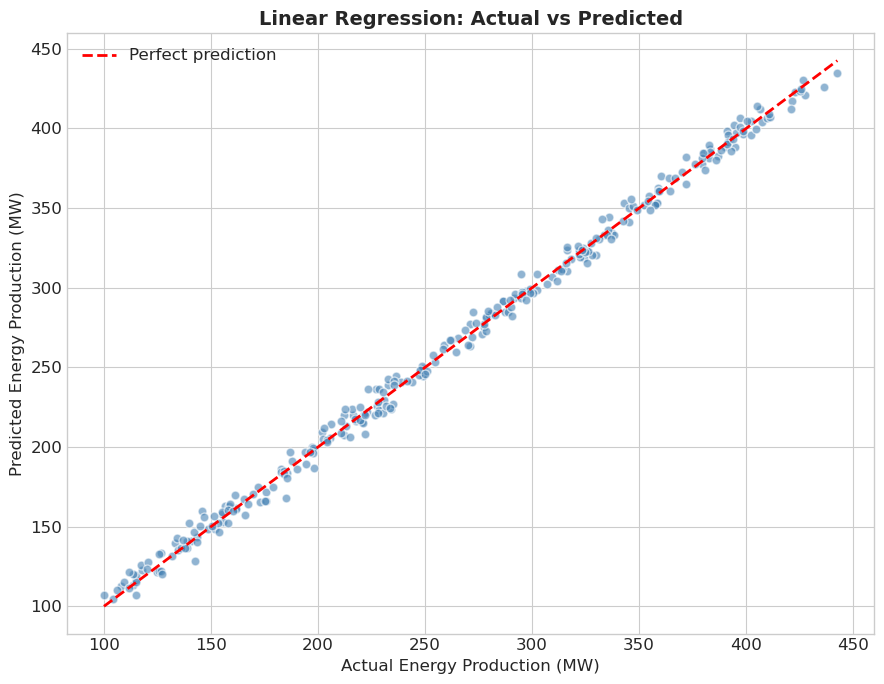

In [9]:
# ── 5.1 Train ─────────────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# ── 5.2 Predict ───────────────────────────────────────────────
y_pred_lr = lr_model.predict(X_test)

# ── 5.3 Evaluate ──────────────────────────────────────────────
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

print('=== LINEAR REGRESSION PERFORMANCE ===')
print(f'MSE:  {mse_lr:.4f}')
print(f'RMSE: {rmse_lr:.4f} MW  <-- primary metric')
print(f'MAE:  {mae_lr:.4f} MW')

# ── 5.4 Feature Coefficients ──────────────────────────────────
coeff_df = pd.DataFrame({
    'Feature':     FEATURES,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print(f'\nModel Intercept: {lr_model.intercept_:.4f}')
print('\n=== FEATURE COEFFICIENTS (sorted by impact) ===')
display(coeff_df)

# ── 5.5 Visualise: Actual vs Predicted ────────────────────────
plt.figure(figsize=(9,7))
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue', edgecolors='white', s=40)
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Energy Production (MW)')
plt.ylabel('Predicted Energy Production (MW)')
plt.title('Linear Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/04_actual_vs_predicted.png', dpi=150)
plt.show()


# ============================================================
# CELL 6 — Residual Analysis
# ============================================================

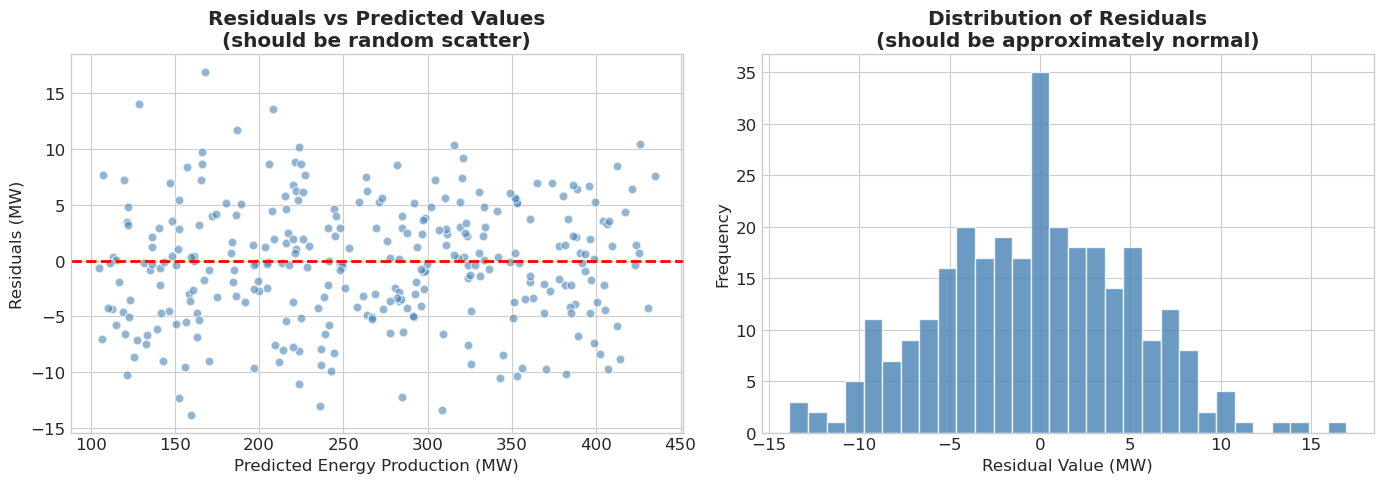

Mean of residuals: -0.343981  (should be close to 0)
Std of residuals:  5.3999


In [10]:
residuals = y_test - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Residuals vs Predicted ───────────────────────────
axes[0].scatter(y_pred_lr, residuals, alpha=0.6, color='steelblue',
                edgecolors='white', s=40)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Energy Production (MW)')
axes[0].set_ylabel('Residuals (MW)')
axes[0].set_title('Residuals vs Predicted Values\n(should be random scatter)', fontweight='bold')

# ── Plot 2: Residual Distribution ────────────────────────────
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residual Value (MW)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals\n(should be approximately normal)', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/05_residual_analysis.png', dpi=150)
plt.show()

print(f'Mean of residuals: {residuals.mean():.6f}  (should be close to 0)')
print(f'Std of residuals:  {residuals.std():.4f}')


# ============================================================
# CELL 7 — SGD Regression: Learning Rate Experiment
# ============================================================

=== SGD RESULTS BY LEARNING RATE ===


,MAE,MSE,RMSE
Learning Rate,,,
0.0001,4.3065,29.1772,5.4016
0.0010,4.3168,29.2866,5.4117
0.0100,4.3297,29.3928,5.4215
0.1000,6.8794,74.6960,8.6427



Best learning rate: 0.0001 (lowest RMSE)


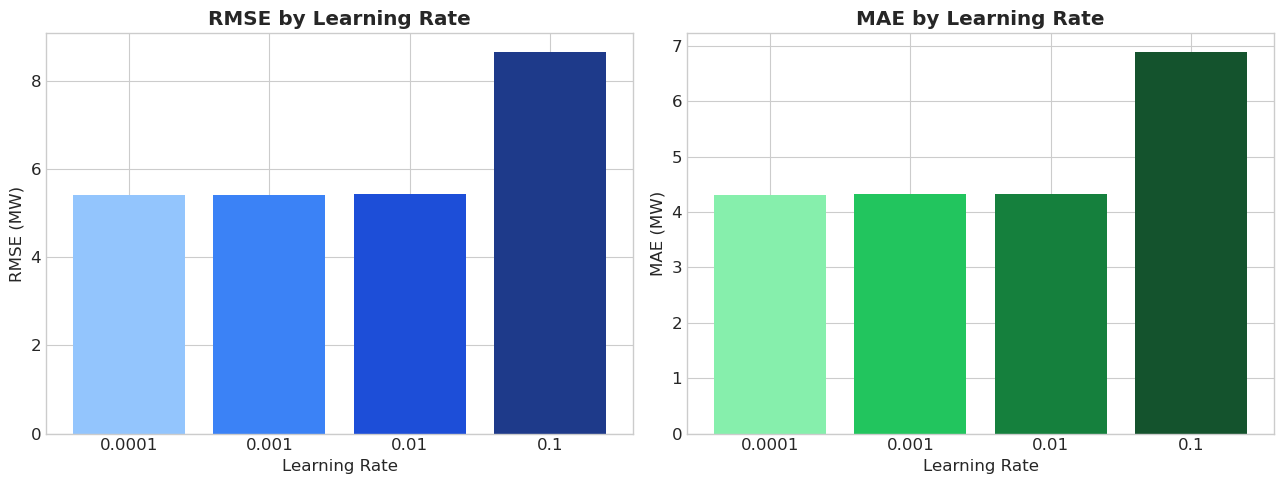

In [11]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
sgd_results = {}

for lr in learning_rates:
    sgd = SGDRegressor(
        learning_rate='constant',
        eta0=lr,
        max_iter=1000,
        random_state=RANDOM_STATE,
        tol=1e-3
    )
    sgd.fit(X_train_scaled, y_train)
    y_pred_sgd = sgd.predict(X_test_scaled)

    sgd_results[lr] = {
        'MAE':  mean_absolute_error(y_test, y_pred_sgd),
        'MSE':  mean_squared_error(y_test, y_pred_sgd),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_sgd))
    }

# ── Results table ─────────────────────────────────────────────
results_df = pd.DataFrame(sgd_results).T.round(4)
results_df.index.name = 'Learning Rate'
print('=== SGD RESULTS BY LEARNING RATE ===')
display(results_df)
best_lr = results_df['RMSE'].idxmin()
print(f'\nBest learning rate: {best_lr} (lowest RMSE)')

# ── Visualise learning rate comparison ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lrs_str = [str(lr) for lr in learning_rates]
rmse_vals = [sgd_results[lr]['RMSE'] for lr in learning_rates]
mae_vals  = [sgd_results[lr]['MAE']  for lr in learning_rates]

axes[0].bar(lrs_str, rmse_vals, color=['#93C5FD','#3B82F6','#1D4ED8','#1E3A8A'])
axes[0].set_title('RMSE by Learning Rate', fontweight='bold')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('RMSE (MW)')

axes[1].bar(lrs_str, mae_vals, color=['#86EFAC','#22C55E','#15803D','#14532D'])
axes[1].set_title('MAE by Learning Rate', fontweight='bold')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('MAE (MW)')

plt.tight_layout()
plt.savefig('outputs/figures/06_sgd_learning_rates.png', dpi=150)
plt.show()


In [12]:
# ============================================================
# CELL 8 — Final Summary & Comparison
# ============================================================

In [13]:
best_sgd = SGDRegressor(learning_rate='constant', eta0=0.01,
                         max_iter=1000, random_state=RANDOM_STATE)
best_sgd.fit(X_train_scaled, y_train)
y_pred_best_sgd = best_sgd.predict(X_test_scaled)

summary = {
    'Model': ['Linear Regression', 'SGD Regression (lr=0.01)'],
    'MSE':   [round(mse_lr, 4),
              round(mean_squared_error(y_test, y_pred_best_sgd), 4)],
    'RMSE':  [round(rmse_lr, 4),
              round(np.sqrt(mean_squared_error(y_test, y_pred_best_sgd)), 4)],
    'MAE':   [round(mae_lr, 4),
              round(mean_absolute_error(y_test, y_pred_best_sgd), 4)],
}

print('===========================')
print(' FINAL MODEL COMPARISON ')
print('===========================')
display(pd.DataFrame(summary))

print('\n=== PROJECT COMPLETE ===')
print('All figures saved to: outputs/figures/')
print('Ready for GitHub push.')


 FINAL MODEL COMPARISON 


,Model,MSE,RMSE,MAE
0,Linear Regression,29.1804,5.4019,4.3072
1,SGD Regression (lr=0.01),29.3928,5.4215,4.3297



=== PROJECT COMPLETE ===
All figures saved to: outputs/figures/
Ready for GitHub push.
